<a href="https://colab.research.google.com/github/mudassar2224/Independent_Component_Analysis-/blob/main/Independent_Component_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA


# **Create Sample Signals**

In [ ]:
time=np.linspace(0, 8, 1000)
# signal one
s1=np.sin(2*time)
#  Signal 2
s2=np.sign(np.sin(3*time))
Signal=np.c_[s1, s2]
# mix Signals
A=np.array([[1, 1], [0.5, 2]])
X=np.dot(Signal, A.T)




# **Apply ICA**

In [ ]:
ICA=FastICA(n_components=2)
Signal_=ICA.fit_transform(X)


# **Plot**

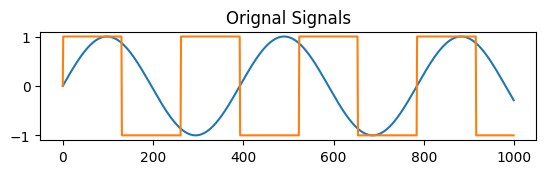

In [ ]:
plt.figure()
plt.subplot(3, 1,1)
plt.title("Orignal Signals")
plt.plot(Signal)
plt.show()

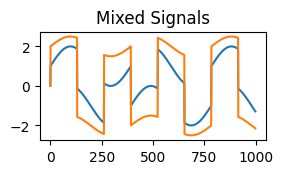

In [ ]:
plt.subplot(3, 2,1 )
plt.title("Mixed Signals")
plt.plot(X)
plt.show()


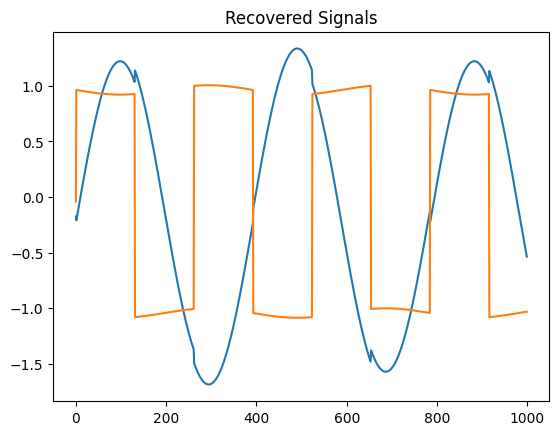

In [ ]:
plt.title("Recovered Signals")
plt.plot(Signal_)
plt.show()

# **EEG Signal Cleaning using ICA**

In [ ]:
import kagglehub

path = kagglehub.dataset_download("amananandrai/complete-eeg-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'complete-eeg-dataset' dataset.
Path to dataset files: /kaggle/input/complete-eeg-dataset


In [ ]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/complete-eeg-dataset/s13.csv
/kaggle/input/complete-eeg-dataset/s11.csv
/kaggle/input/complete-eeg-dataset/s01.csv
/kaggle/input/complete-eeg-dataset/s25.csv
/kaggle/input/complete-eeg-dataset/s03.csv
/kaggle/input/complete-eeg-dataset/s16.csv
/kaggle/input/complete-eeg-dataset/s00.csv
/kaggle/input/complete-eeg-dataset/s23.csv
/kaggle/input/complete-eeg-dataset/s08.csv
/kaggle/input/complete-eeg-dataset/s07.csv
/kaggle/input/complete-eeg-dataset/s14.csv
/kaggle/input/complete-eeg-dataset/s31.csv
/kaggle/input/complete-eeg-dataset/s27.csv
/kaggle/input/complete-eeg-dataset/s29.csv
/kaggle/input/complete-eeg-dataset/s18.csv
/kaggle/input/complete-eeg-dataset/s33.csv
/kaggle/input/complete-eeg-dataset/s26.csv
/kaggle/input/complete-eeg-dataset/s17.csv
/kaggle/input/complete-eeg-dataset/s05.csv
/kaggle/input/complete-eeg-dataset/s28.csv
/kaggle/input/complete-eeg-dataset/s21.csv
/kaggle/input/complete-eeg-dataset/s20.csv
/kaggle/input/complete-eeg-dataset/s12.csv
/kaggle/inp

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA

In [ ]:
file_path = "/root/.cache/kagglehub/datasets/amananandrai/complete-eeg-dataset/versions/1/s15.csv"
data = pd.read_csv(file_path)

print("Shape of CSV:", data.shape)
print("Columns:", data.columns)

Shape of CSV: (30999, 19)
Columns: Index(['-1.4357', '8.4364', '4.9183', '7.9344', '15.527', '-3.159', '1.151',
       '-4.237', '2.6138', '2.1244', '-11.696', '-10.957', '-0.60014',
       '-0.80884', '-1.6133', '-2.2079', '2.0231', '5.6394', '2.7738'],
      dtype='object')


In [ ]:
# Keep only numeric columns (EEG signals)
data_numeric = data.select_dtypes(include=['float64', 'int64'])
print("EEG numeric data shape:", data_numeric.shape)

EEG numeric data shape: (30999, 19)


In [ ]:
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(data_numeric)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (30999, 19)


In [ ]:
ica = FastICA(n_components=19, random_state=42)  # 10 components for example
X_ica = ica.fit_transform(X_scaled)

print("ICA components shape:", X_ica.shape)

ICA components shape: (30999, 19)


In [ ]:
# 1. Handle missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(data_numeric)

# 2. Scale the data (Mean=0, Std=1)
# ICA requires scaled data to identify independent variances
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("Preprocessing Complete.")

Preprocessing Complete.


In [ ]:
# 1. Run ICA (15 components is usually enough for a standard CSV)
n_comp = 19
ica = FastICA(n_components=n_comp, random_state=42, max_iter=1000)
X_ica = ica.fit_transform(X_scaled)

# 2. AUTOMATIC ARTIFACT DETECTION
# We calculate Kurtosis (spikiness) for every component
kurt_vals = [kurtosis(X_ica[:, i]) for i in range(n_comp)]
skew_vals = [skew(X_ica[:, i]) for i in range(n_comp)]

# Thresholds: Kurtosis > 8 usually captures Eye Blinks/Spikes
k_threshold = 8
s_threshold = 2

auto_bad_indices = []
for i in range(n_comp):
    if abs(kurt_vals[i]) > k_threshold or abs(skew_vals[i]) > s_threshold:
        auto_bad_indices.append(i)

print(f"Successfully identified {len(auto_bad_indices)} noise components: {auto_bad_indices}")

# 3. Zero out the bad components automatically
X_ica_filtered = X_ica.copy()
for idx in auto_bad_indices:
    X_ica_filtered[:, idx] = 0

# 4. Reconstruct the clean signal
X_clean = ica.inverse_transform(X_ica_filtered)

Successfully identified 2 noise components: [2, 9]


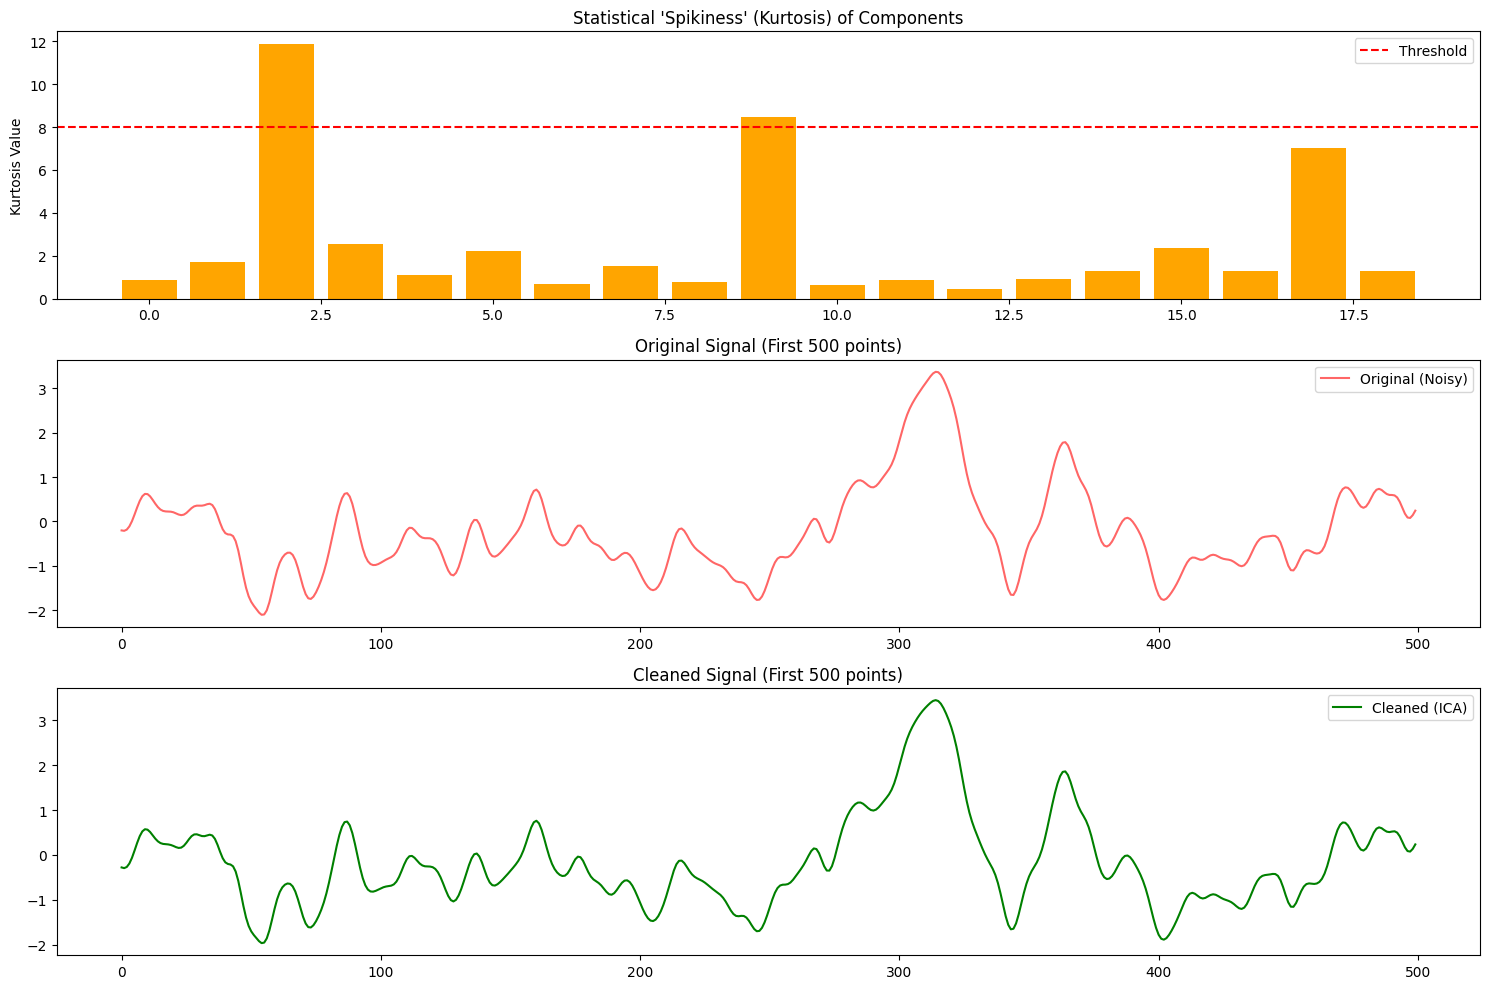

In [ ]:
plt.figure(figsize=(15, 10))

# Plot the Kurtosis levels to see why components were flagged
plt.subplot(3, 1, 1)
plt.bar(range(n_comp), kurt_vals, color='orange')
plt.axhline(y=k_threshold, color='red', linestyle='--', label='Threshold')
plt.title("Statistical 'Spikiness' (Kurtosis) of Components")
plt.ylabel("Kurtosis Value")
plt.legend()

# Plot Original vs Cleaned (First Channel)
plt.subplot(3, 1, 2)
plt.plot(X_scaled[:500, 0], label="Original (Noisy)", color='red', alpha=0.6)
plt.title("Original Signal (First 500 points)")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(X_clean[:500, 0], label="Cleaned (ICA)", color='green')
plt.title("Cleaned Signal (First 500 points)")
plt.legend()

plt.tight_layout()
plt.show()

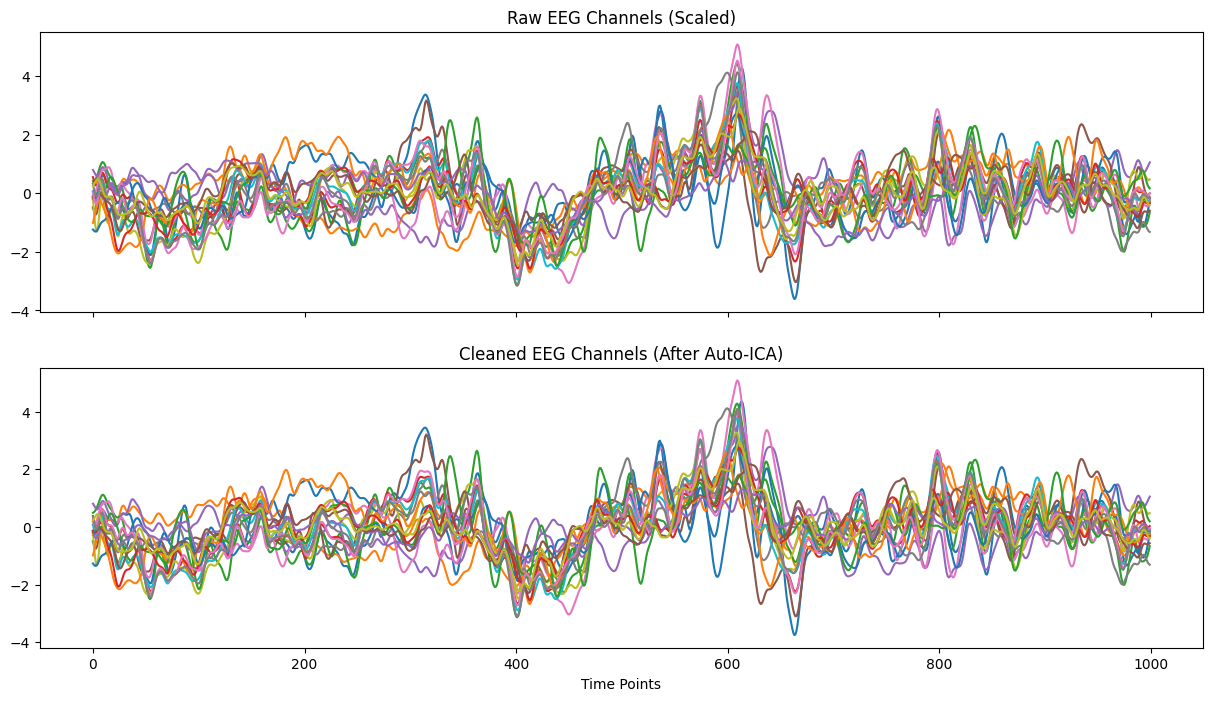

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax1.plot(X_scaled[:1000])
ax1.set_title("Raw EEG Channels (Scaled)")

ax2.plot(X_clean[:1000])
ax2.set_title("Cleaned EEG Channels (After Auto-ICA)")

plt.xlabel("Time Points")
plt.show()